In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(
    "../datasets/stock/synthetic_stock_data.csv"
)

In [3]:
df.head()

,date,location,item,opening_stock,received,issued,closing_stock,lead_time_days,criticality,supplier
0,2025-01-01,Hospital A,Paracetamol,175,46,59,162,5,High,Supplier Y
1,2025-01-01,Hospital A,Amoxicillin,152,18,4,166,6,High,Supplier X
2,2025-01-01,Hospital A,Rice,69,30,14,85,3,Medium,Supplier Y
3,2025-01-01,Hospital A,Flour,164,43,146,61,2,Medium,Supplier Y
4,2025-01-01,Hospital B,Paracetamol,115,48,86,77,2,High,Supplier X


In [4]:
df.shape

(4380, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4380 entries, 0 to 4379
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   date            4380 non-null   object
 1   location        4380 non-null   object
 2   item            4380 non-null   object
 3   opening_stock   4380 non-null   int64 
 4   received        4380 non-null   int64 
 5   issued          4380 non-null   int64 
 6   closing_stock   4380 non-null   int64 
 7   lead_time_days  4380 non-null   int64 
 8   criticality     4380 non-null   object
 9   supplier        4380 non-null   object
dtypes: int64(5), object(5)
memory usage: 342.3+ KB


In [6]:
df.columns


Index(['date', 'location', 'item', 'opening_stock', 'received', 'issued',
       'closing_stock', 'lead_time_days', 'criticality', 'supplier'],
      dtype='object')

In [7]:
df.describe()

,opening_stock,received,issued,closing_stock,lead_time_days
count,4380.000000,4380.000000,4380.000000,4380.000000,4380.00000
mean,124.243151,24.755023,74.748402,74.249772,4.00274
std,43.170210,14.382821,50.086946,49.372488,1.42579
min,50.000000,0.000000,0.000000,1.000000,2.00000
25%,87.000000,12.000000,34.000000,34.000000,3.00000
50%,125.000000,25.000000,68.000000,67.000000,4.00000
75%,161.000000,37.000000,110.000000,107.000000,5.00000
max,199.000000,49.000000,234.000000,236.000000,6.00000


In [8]:
df.isnull().sum()

date              0
location          0
item              0
opening_stock     0
received          0
issued            0
closing_stock     0
lead_time_days    0
criticality       0
supplier          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["date"]=pd.to_datetime(df["date"])

In [11]:
df["month"]=df["date"].dt.month
df["day"]=df["date"].dt.day

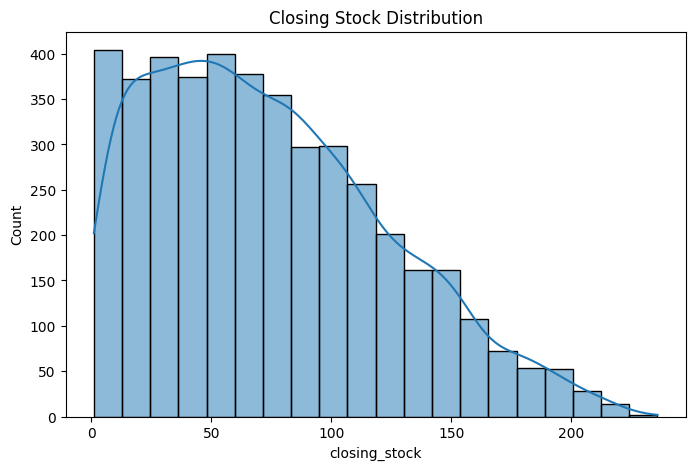

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["closing_stock"],
    bins=20,
    kde=True
)
plt.title("Closing Stock Distribution")
plt.show()

In [13]:
df["closing_stock"].describe()

count    4380.000000
mean       74.249772
std        49.372488
min         1.000000
25%        34.000000
50%        67.000000
75%       107.000000
max       236.000000
Name: closing_stock, dtype: float64

In [16]:
def inventory_status(stock):
    if(stock<50):
        return "Critical"
    elif stock<100:
        return "Warning"
    else:
        return "Healthy"

In [17]:
df["Inventory_Status"]=(
    df["closing_stock"].apply(inventory_status)
)

In [19]:
df[
    [
        "item",
        "closing_stock",
        "Inventory_Status"
    ]
].head()

,item,closing_stock,Inventory_Status
0,Paracetamol,162,Healthy
1,Amoxicillin,166,Healthy
2,Rice,85,Warning
3,Flour,61,Warning
4,Paracetamol,77,Warning


In [20]:
df["Inventory_Status"].value_counts()

Inventory_Status
Critical    1607
Warning     1504
Healthy     1269
Name: count, dtype: int64

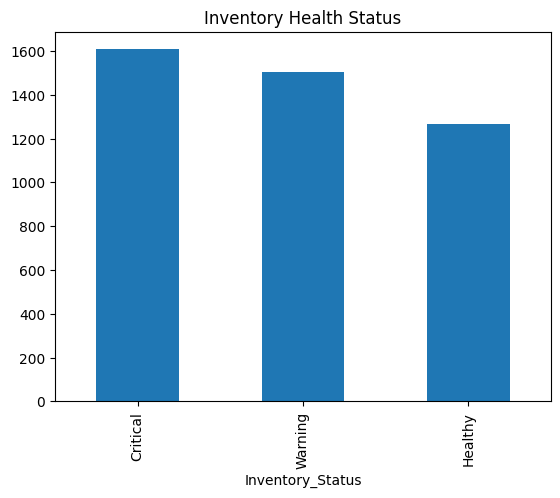

In [21]:
df["Inventory_Status"]\
.value_counts()\
.plot(kind="bar")

plt.title("Inventory Health Status")
plt.show()

In [25]:
def reorder_recommendation(stock):
    if stock < 50:
        return "Reorder Immediately"
    elif stock < 100:
        return "Reorder Soon"
    else:
        return "No Action Required"

In [27]:
df["Recommendation"] = (
    df["closing_stock"].apply(reorder_recommendation)
)

In [34]:
df["Alert"]=np.where(
    df["closing_stock"]<50,
    "Low Stock Alert",
    "OK"
)

In [35]:
df[
    [
        "item",
        "closing_stock",
        "Inventory_Status",
        "Recommendation",
        "Alert"
    ]
].head()

,item,closing_stock,Inventory_Status,Recommendation,Alert
0,Paracetamol,162,Healthy,No Action Required,OK
1,Amoxicillin,166,Healthy,No Action Required,OK
2,Rice,85,Warning,Reorder Soon,OK
3,Flour,61,Warning,Reorder Soon,OK
4,Paracetamol,77,Warning,Reorder Soon,OK


In [39]:
inventory_dashboard=df[
    [
        "date",
        "location",
        "item",
        "closing_stock",
        "Inventory_Status",
        "Recommendation",
        "Alert",
        "supplier"
    ]
]

In [40]:
inventory_dashboard.head()


,date,location,item,closing_stock,Inventory_Status,Recommendation,Alert,supplier
0,2025-01-01,Hospital A,Paracetamol,162,Healthy,No Action Required,OK,Supplier Y
1,2025-01-01,Hospital A,Amoxicillin,166,Healthy,No Action Required,OK,Supplier X
2,2025-01-01,Hospital A,Rice,85,Warning,Reorder Soon,OK,Supplier Y
3,2025-01-01,Hospital A,Flour,61,Warning,Reorder Soon,OK,Supplier Y
4,2025-01-01,Hospital B,Paracetamol,77,Warning,Reorder Soon,OK,Supplier X


In [44]:
import os
print(os.getcwd())

c:\Users\hiii\OneDrive\Desktop\Smart-Pharmacy-Predictive-Analytics\notebooks


In [46]:
os.makedirs("../outputs", exist_ok=True)

In [47]:
inventory_dashboard.to_csv(
    "../outputs/inventory_alerts.csv",
    index=False
)

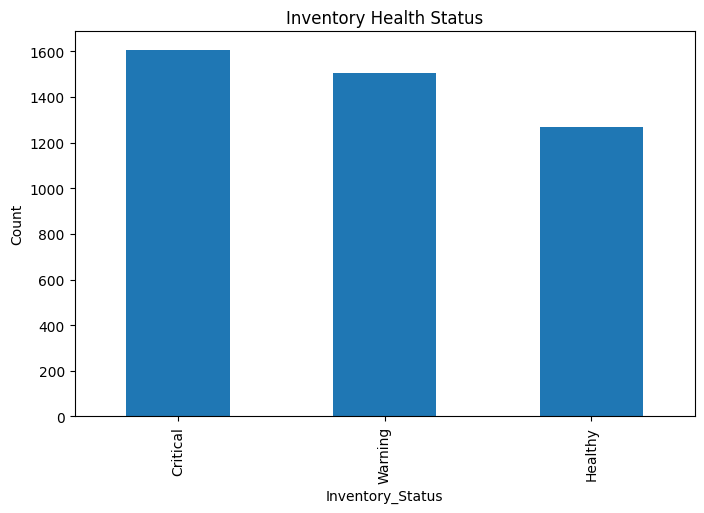

In [49]:
plt.figure(figsize=(8,5))
df["Inventory_Status"]\
.value_counts()\
.plot(kind="bar")

plt.title("Inventory Health Status")
plt.ylabel("Count")
plt.show()

Text(0.5, 1.0, 'Inventory Status by Location')

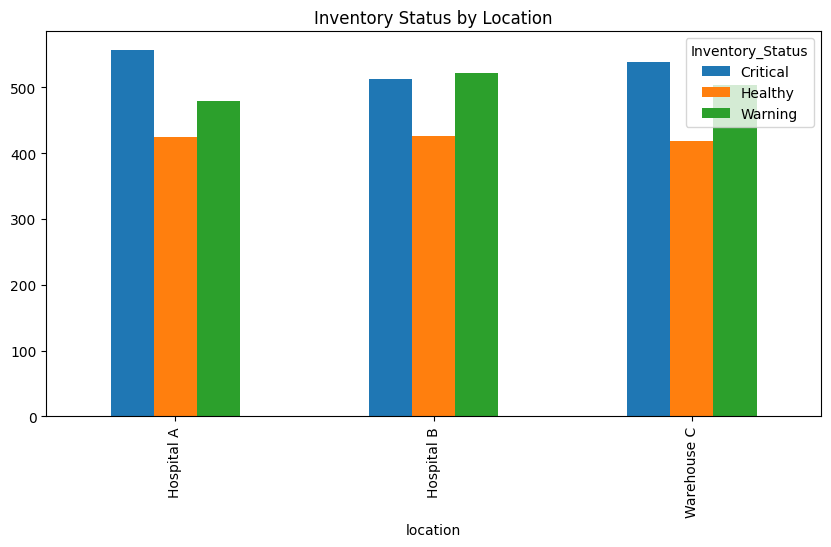

In [50]:
location_status=pd.crosstab(
    df["location"],
    df["Inventory_Status"]
)
location_status.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Inventory Status by Location")

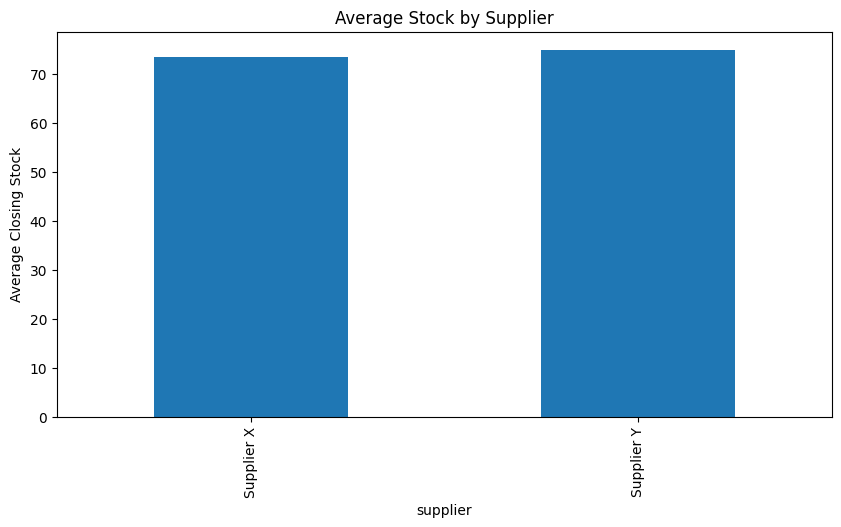

In [51]:
supplier_stock=(
    df.groupby("supplier")["closing_stock"]
    .mean()
    .sort_values()
)
supplier_stock.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Average Stock by Supplier")
plt.ylabel("Average Closing Stock")

plt.show()

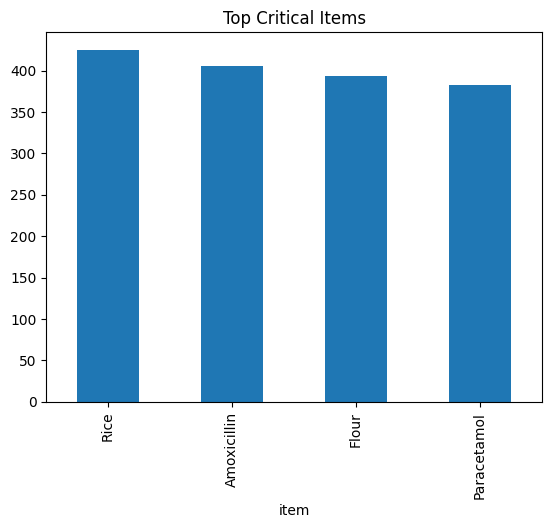

In [53]:
critical_items=df[
    df["Inventory_Status"]=="Critical"
]

critical_items["item"]\
.value_counts()\
.head(10)\
.plot(kind="bar")
plt.title("Top Critical Items")
plt.show()

In [54]:
def advanced_recommendation(stock, lead_time):
    if stock<50 and lead_time>7:
        return "Urgent Reorder"
    elif stock<50:
        return "Reorder Immediately"
    elif stock<100:
        return "Reorder Soon"
    else:
        return "No Action Required"

In [55]:
df["Advanced_Recommendation"]=df.apply(
    lambda row: advanced_recommendation(
        row["closing_stock"],
        row["lead_time_days"]
    ),
    axis=1
)

In [56]:
inventory_dashboard.to_csv(
    "../outputs/inventory_alerts.csv",
    index=False
)